In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

## Part 1
Load the data and split it in training,validation and testing sets

In [5]:
df = pd.read_csv("./data/fer2013.csv")

print( df['Usage'].value_counts() )

Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


In [6]:
# We use for training and validation the "Training" and "PublicTest"
trai_df = df[df['Usage']== 'Training'].copy()
vali_df = df[df['Usage'] == 'PublicTest'].copy()
test_df = df[df['Usage'] == 'PrivateTest'].copy() 

# Storing train and test data frames
trai_df.to_csv("./data/fer2013_train.csv", encoding='utf-8', index=False)
vali_df.to_csv("./data/fer2013_validation.csv", encoding='utf-8', index=False)
test_df.to_csv("./data/fer2013_test.csv", encoding='utf-8', index=False)

## Part 2
statistics and labelling

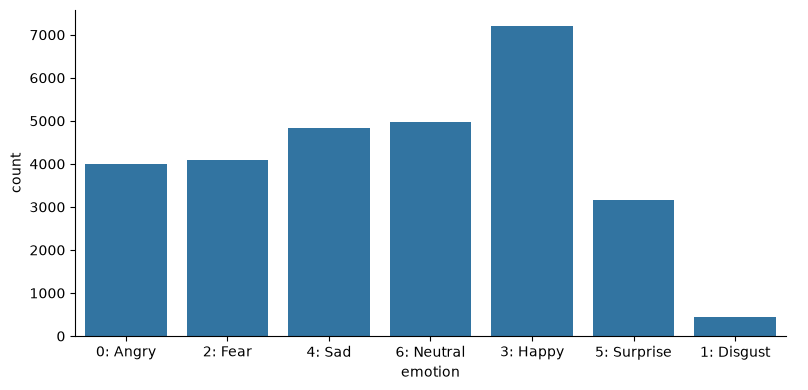

In [7]:
emotionDict = {
    0:'0: Angry',
    1:'1: Disgust',
    2:'2: Fear',
    3:'3: Happy',
    4:'4: Sad',
    5:'5: Surprise',
    6:'6: Neutral'
}


sns.catplot(data=trai_df.replace({'emotion': emotionDict}), kind='count', x='emotion', height=4, aspect=2)

plt.show()

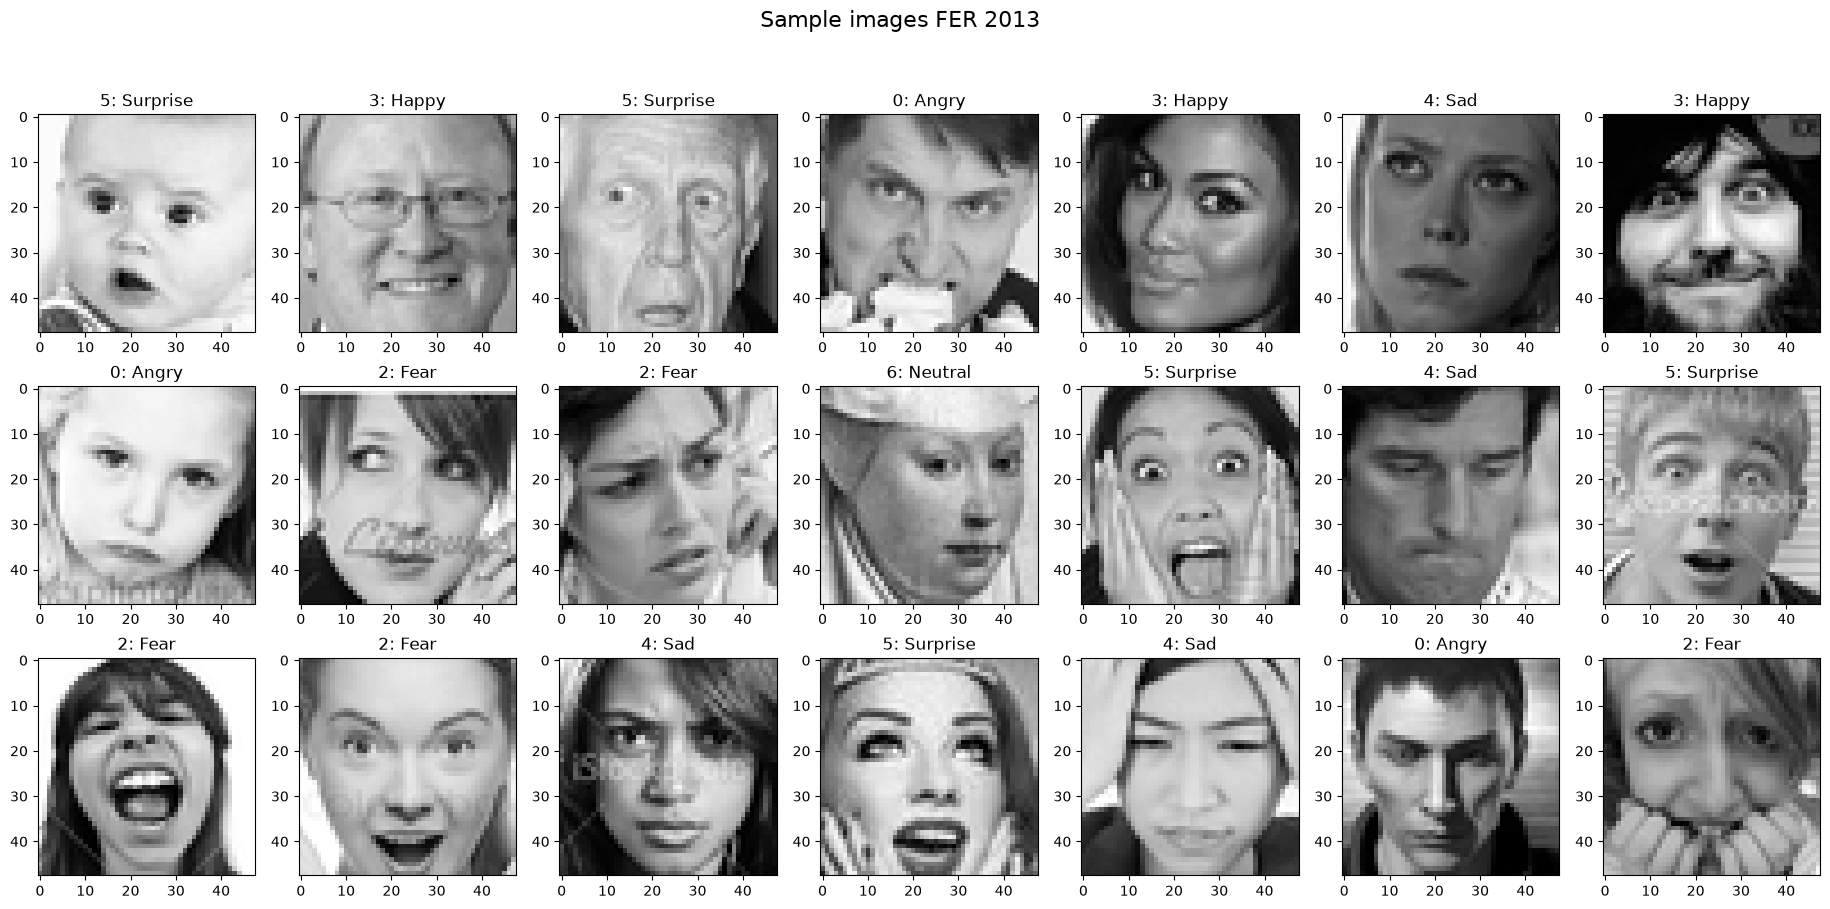

In [8]:
# Now making some plots
random_rows = df.sample(n=21, random_state=43)
imgs = [np.fromstring(pixels, sep=' ').reshape(48, 48) for pixels in random_rows['pixels']]
lbl =  random_rows['emotion'].values

fig, axes = plt.subplots(nrows=3, ncols=7, figsize=(23, 10))
fig.suptitle('Sample images FER 2013', fontsize=16)

# Loop through each subplot and customize
for i in range(7):
    for j in range(3):
        ax = axes[j, i]
        ax.imshow(imgs[j*7+i], cmap="gray") 
        ax.set_title('%s'%(emotionDict[lbl[j*7+i]]))
        #ax.grid(True)
plt.show()


Compyting the class weights for the training test

In [9]:
csv_file = './data/fer2013_train.csv'
model_file = "./models/rf_fer_model_landmarks.pkl"

## Loading the Data

In [10]:
from sklearn.utils.class_weight import compute_class_weight

trai_df = pd.read_csv(csv_file)

# Computing class weights for unbalanced dataset
labelsTrain = trai_df['emotion'].values
cw = compute_class_weight(
    class_weight="balanced", classes=np.unique(labelsTrain), y=labelsTrain)
#class_weights = {0:cw[0],1:cw[1],2:cw[2], 3:cw[3], 4:cw[4], 5:cw[5], 6:cw[6]}

## Feature extraction pipeline

In [11]:
import dlib 

# Importing dlib's landmark detector
# Dlib landmarks from: 
#   https://github.com/davisking/dlib-models/blob/master/shape_predictor_68_face_landmarks.dat.bz2
landmDet = dlib.shape_predictor("faceAndLandmarkModels/shape_predictor_68_face_landmarks.dat")


def extractLandmarksFER(images):
    face_rects = dlib.rectangle(left=1, top=1, right=47, bottom=47)
    x1 = face_rects.left() 
    y1 = face_rects.top() 
    x2 = face_rects.right() 
    y2 = face_rects.bottom()

    landm = []
    for img in images:
        la = landmDet(img.astype(np.uint8), face_rects)

        # This works better if the standard scaler is not usec
        la2 = np.asarray( np.matrix([
            [
                (p.x-0.5*(x2-x1))/(x2-x1), (p.y-0.5*(y2-y1))/(y2-y1)
            ] for p in la.parts()])).astype(np.float32)
        la2 -= np.mean(la2, axis=0, keepdims=True)
        la2 /= np.max(np.abs(la2), axis=0, keepdims=True)

        landm.append(la2.flatten())
    feats = np.stack(landm)
    return(feats)

# Loading the images
images = np.array(
        [np.fromstring(pixels, sep=' ').reshape(48, 48) for pixels in trai_df['pixels']])
feats = extractLandmarksFER(images)

images = None

## Evaluating the results

Random Forest + Landmarks

In [12]:
from sklearn.ensemble import RandomForestClassifier
import joblib


rf = RandomForestClassifier(
    n_estimators=300,       # Number of trees
    max_depth=11,           # Allow trees to grow fully
    max_features='sqrt',   # Use sqrt(features) for splitting
    random_state=42,
    n_jobs=-1,             # Use all available CPU cores 
    #class_weight= "balanced", #class_weights,
    criterion="entropy",
)


rf.fit(feats, trai_df['emotion'].values)

joblib.dump(rf, model_file)
print(f"Model saved to {model_file}")

Model saved to ./models/rf_fer_model_landmarks.pkl


Perform to validation test and Confusion Matrix Random Forest + Landmarks

Accuracy: 0.48
Balanced accuracy: 0.41
Macro F1: 0.41


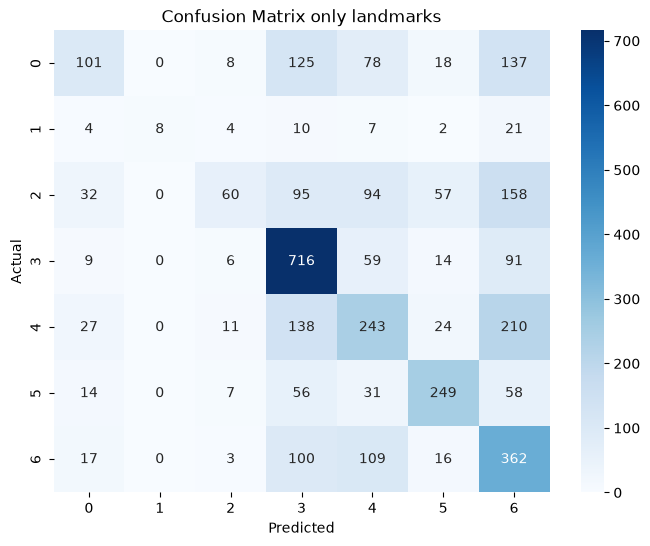

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, balanced_accuracy_score, f1_score

def preprocessingFer(dataFrame):
    # Convert pixel strings to 48x48 images
    images = np.array(
        [np.fromstring(pixels, sep=' ').reshape(48, 48) for pixels in dataFrame['pixels']])
    X =  extractLandmarksFER(images)
    y = dataFrame['emotion'].values
    return([X,y])


# Predict and evaluate
valid = pd.read_csv('./data/fer2013_validation.csv')
X_valid, y_valid = preprocessingFer(valid)

y_pred = rf.predict(X_valid)
accuracy = accuracy_score(y_valid, y_pred)
conf_matrix = confusion_matrix(y_valid, y_pred)

baccuracy = balanced_accuracy_score(y_valid, y_pred)
macro_f1 = f1_score(y_valid, y_pred, average='macro')


# Print results
print(f"Accuracy: {accuracy:.2f}")
print(f"Balanced accuracy: {baccuracy:.2f}")
print(f"Macro F1: {macro_f1:.2f}")


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix only landmarks")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Logistic Regression + Landmarks

In [14]:
from sklearn.linear_model import LogisticRegression

In [16]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(feats, labelsTrain)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


Evaluate Logistic Regression + Landmarks on the Validation Set

In [17]:
y_pred_lr = lr.predict(X_valid)

accuracy_lr = accuracy_score(y_valid, y_pred_lr)
baccuracy_lr = balanced_accuracy_score(y_valid, y_pred_lr)
macro_f1_lr = f1_score(y_valid, y_pred_lr, average='macro')

conf_matrix_lr = confusion_matrix(y_valid, y_pred_lr)

print(f"Accuracy: {accuracy_lr:.2f}")
print(f"Balanced accuracy: {baccuracy_lr:.2f}")
print(f"Macro F1: {macro_f1_lr:.2f}")

Accuracy: 0.48
Balanced accuracy: 0.39
Macro F1: 0.37


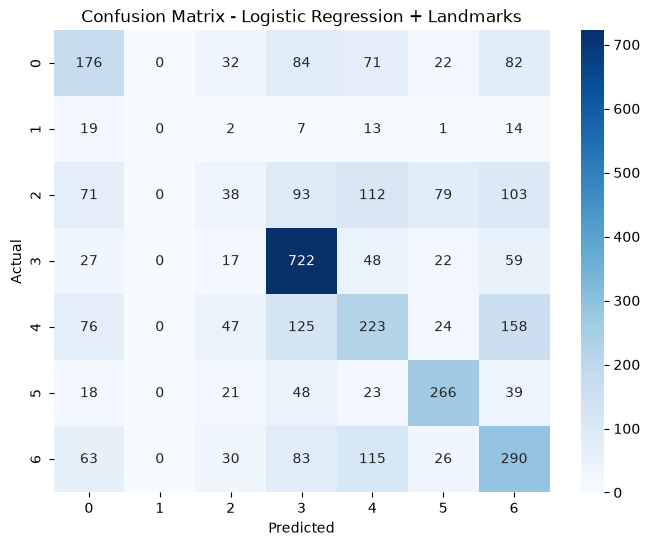

In [39]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression + Landmarks")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

SVM + Landmarks

In [18]:
from sklearn.svm import SVC

In [19]:
svm = SVC(
    kernel='rbf',
    random_state=42
)

svm.fit(feats, labelsTrain)

print("SVM trained successfully")

SVM trained successfully


Validation

In [20]:
# Evaluate SVM on the Validation Set

y_pred_svm = svm.predict(X_valid)

accuracy_svm = accuracy_score(y_valid, y_pred_svm)
baccuracy_svm = balanced_accuracy_score(y_valid, y_pred_svm)
macro_f1_svm = f1_score(y_valid, y_pred_svm, average='macro')

conf_matrix_svm = confusion_matrix(y_valid, y_pred_svm)

print(f"Accuracy: {accuracy_svm:.2f}")
print(f"Balanced accuracy: {baccuracy_svm:.2f}")
print(f"Macro F1: {macro_f1_svm:.2f}")

Accuracy: 0.46
Balanced accuracy: 0.37
Macro F1: 0.35


Confusion Matrix

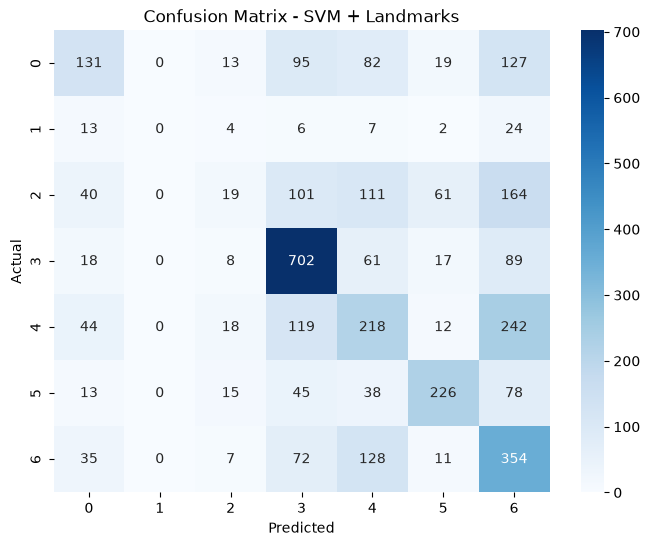

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - SVM + Landmarks")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## HOG Feature extraction

In [23]:
from skimage.feature import hog

def extractHOG(images):
    hog_features = []

    for img in images:
        features = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )
        hog_features.append(features)

    return np.array(hog_features)

Extract training features

In [25]:
 ##Extract HOG features from the training images

images_train = np.array(
    [np.fromstring(pixels, sep=' ').reshape(48, 48)
     for pixels in trai_df['pixels']]
)

hog_feats = extractHOG(images_train)

images_train = None

print("HOG feature shape:", hog_feats.shape)

HOG feature shape: (28709, 900)


Random Forest + HOG

In [26]:
# Random Forest + HOG

rf_hog = RandomForestClassifier(
    n_estimators=300,
    max_depth=11,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    criterion="entropy"
)

rf_hog.fit(hog_feats, labelsTrain)

print("Random Forest + HOG trained successfully")

Random Forest + HOG trained successfully


Validation Random Forest + HOG

In [27]:
images_valid = np.array(
    [np.fromstring(pixels, sep=' ').reshape(48, 48)
     for pixels in valid['pixels']]
)

hog_valid = extractHOG(images_valid)

images_valid = None

y_pred_rf_hog = rf_hog.predict(hog_valid)

accuracy_rf_hog = accuracy_score(y_valid, y_pred_rf_hog)
baccuracy_rf_hog = balanced_accuracy_score(y_valid, y_pred_rf_hog)
macro_f1_rf_hog = f1_score(y_valid, y_pred_rf_hog, average='macro')

conf_matrix_rf_hog = confusion_matrix(y_valid, y_pred_rf_hog)

print(f"Accuracy: {accuracy_rf_hog:.2f}")
print(f"Balanced accuracy: {baccuracy_rf_hog:.2f}")
print(f"Macro F1: {macro_f1_rf_hog:.2f}")

Accuracy: 0.45
Balanced accuracy: 0.38
Macro F1: 0.39


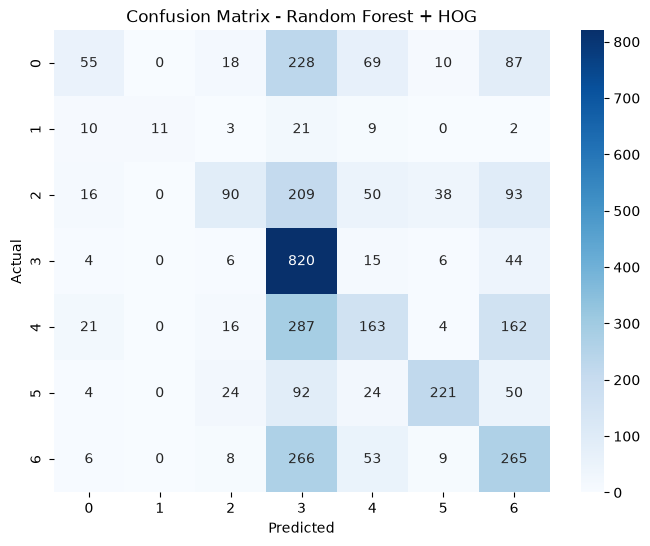

In [28]:
## Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf_hog, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Random Forest + HOG")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Logistic Regression + HOG

Scaling

In [41]:
from sklearn.preprocessing import StandardScaler

scaler_hog = StandardScaler()

hog_feats_scaled = scaler_hog.fit_transform(hog_feats)

print("Scaled HOG shape:", hog_feats_scaled.shape)

Scaled HOG shape: (28709, 900)


In [42]:
lr_hog = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_hog.fit(hog_feats_scaled, labelsTrain)

print("Logistic Regression + HOG trained successfully")

Logistic Regression + HOG trained successfully


Validation Test Logistic Regression + HOG

In [43]:
hog_valid_scaled = scaler_hog.transform(hog_valid)

y_pred_lr_hog = lr_hog.predict(hog_valid_scaled)

accuracy_lr_hog = accuracy_score(y_valid, y_pred_lr_hog)
baccuracy_lr_hog = balanced_accuracy_score(y_valid, y_pred_lr_hog)
macro_f1_lr_hog = f1_score(y_valid, y_pred_lr_hog, average='macro')

conf_matrix_lr_hog = confusion_matrix(y_valid, y_pred_lr_hog)

print(f"Accuracy: {accuracy_lr_hog:.2f}")
print(f"Balanced accuracy: {baccuracy_lr_hog:.2f}")
print(f"Macro F1: {macro_f1_lr_hog:.2f}")

Accuracy: 0.43
Balanced accuracy: 0.40
Macro F1: 0.39


Confusion Matrix Logistic Regression + HOG

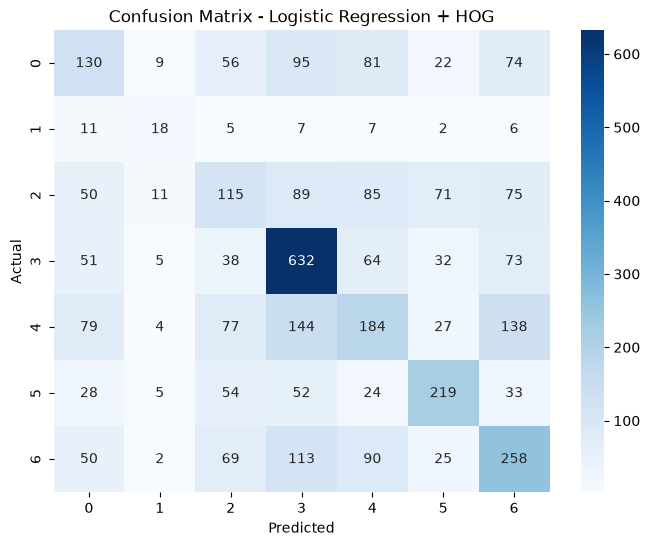

In [44]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lr_hog, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression + HOG")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

SVM + HOG

In [45]:
svm_hog = SVC(
    kernel='rbf',
    random_state=42
)

svm_hog.fit(hog_feats, labelsTrain)

print("SVM + HOG trained successfully")

SVM + HOG trained successfully


Validation Test SVM + HOG

In [46]:
y_pred_svm_hog = svm_hog.predict(hog_valid)

accuracy_svm_hog = accuracy_score(y_valid, y_pred_svm_hog)
baccuracy_svm_hog = balanced_accuracy_score(y_valid, y_pred_svm_hog)
macro_f1_svm_hog = f1_score(y_valid, y_pred_svm_hog, average='macro')

conf_matrix_svm_hog = confusion_matrix(y_valid, y_pred_svm_hog)

print(f"Accuracy: {accuracy_svm_hog:.2f}")
print(f"Balanced accuracy: {baccuracy_svm_hog:.2f}")
print(f"Macro F1: {macro_f1_svm_hog:.2f}")

Accuracy: 0.54
Balanced accuracy: 0.47
Macro F1: 0.50


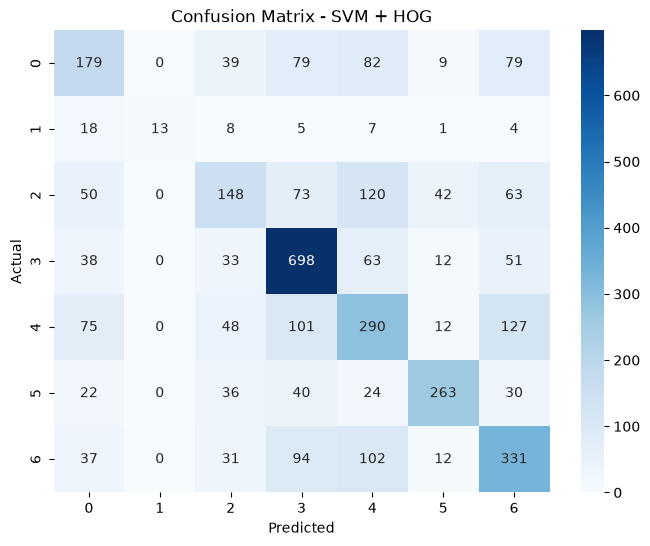

In [47]:
##Confusion Matrix

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm_hog, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - SVM + HOG")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## PCA

In [29]:
from sklearn.decomposition import PCA

# Prepare training images as flattened pixel vectors

images_train = np.array(
    [np.fromstring(pixels, sep=' ').reshape(48, 48)
     for pixels in trai_df['pixels']]
)

X_pixels_train = images_train.reshape(len(images_train), -1)

images_train = None

print("Original feature shape:", X_pixels_train.shape)

Original feature shape: (28709, 2304)


In [30]:
pca = PCA(
    n_components=0.95,
    random_state=42
)

X_pca_train = pca.fit_transform(X_pixels_train)

print("PCA feature shape:", X_pca_train.shape)
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.2f}")

PCA feature shape: (28709, 253)
Explained variance: 0.95


Scaling

In [ ]:
scaler_pca = StandardScaler()

X_pca_train_scaled = scaler_pca.fit_transform(X_pca_train)

Logistic Regression + PCA

In [36]:
lr_pca = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_pca.fit(X_pca_train_scaled, labelsTrain)

print("Logistic Regression + PCA trained successfully")

Logistic Regression + PCA trained successfully


Evaluate Logistic Regression + PCA on the Validation Set

In [37]:

images_valid = np.array(
    [np.fromstring(pixels, sep=' ').reshape(48, 48)
     for pixels in valid['pixels']]
)

X_pixels_valid = images_valid.reshape(len(images_valid), -1)

images_valid = None

# Apply the already-fitted PCA
X_pca_valid = pca.transform(X_pixels_valid)

# Apply the already-fitted scaler
X_pca_valid_scaled = scaler_pca.transform(X_pca_valid)

y_pred_lr_pca = lr_pca.predict(X_pca_valid_scaled)

accuracy_lr_pca = accuracy_score(y_valid, y_pred_lr_pca)
baccuracy_lr_pca = balanced_accuracy_score(y_valid, y_pred_lr_pca)
macro_f1_lr_pca = f1_score(y_valid, y_pred_lr_pca, average='macro')

conf_matrix_lr_pca = confusion_matrix(y_valid, y_pred_lr_pca)

print(f"Accuracy: {accuracy_lr_pca:.2f}")
print(f"Balanced accuracy: {baccuracy_lr_pca:.2f}")
print(f"Macro F1: {macro_f1_lr_pca:.2f}")

Accuracy: 0.38
Balanced accuracy: 0.30
Macro F1: 0.29


Confusion Matrix - Logistic Regression + PCA

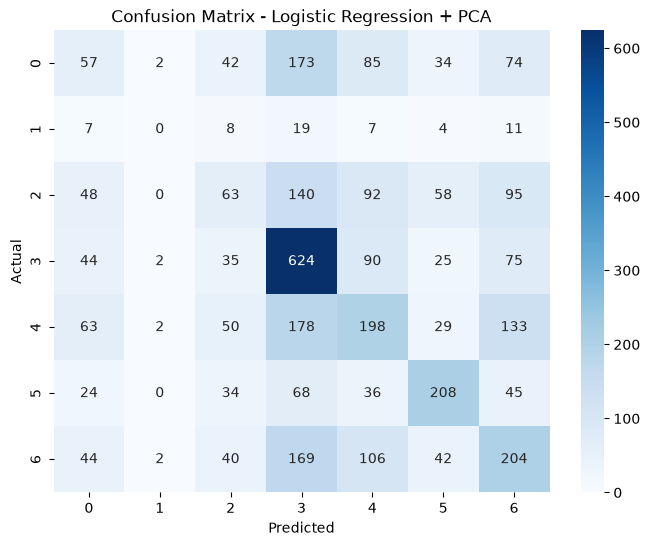

In [38]:


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lr_pca, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression + PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest + PCA

In [48]:
rf_pca = RandomForestClassifier(
    n_estimators=300,
    max_depth=11,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    criterion="entropy"
)

rf_pca.fit(X_pca_train, labelsTrain)

print("Random Forest + PCA trained successfully")

Random Forest + PCA trained successfully


Evaluate Random Forest + PCA in the validation test

In [49]:
y_pred_rf_pca = rf_pca.predict(X_pca_valid)

accuracy_rf_pca = accuracy_score(y_valid, y_pred_rf_pca)
baccuracy_rf_pca = balanced_accuracy_score(y_valid, y_pred_rf_pca)
macro_f1_rf_pca = f1_score(y_valid, y_pred_rf_pca, average='macro')

conf_matrix_rf_pca = confusion_matrix(y_valid, y_pred_rf_pca)

print(f"Accuracy: {accuracy_rf_pca:.2f}")
print(f"Balanced accuracy: {baccuracy_rf_pca:.2f}")
print(f"Macro F1: {macro_f1_rf_pca:.2f}")

Accuracy: 0.35
Balanced accuracy: 0.27
Macro F1: 0.26


Confusion Matrix - Random Forest + PCA

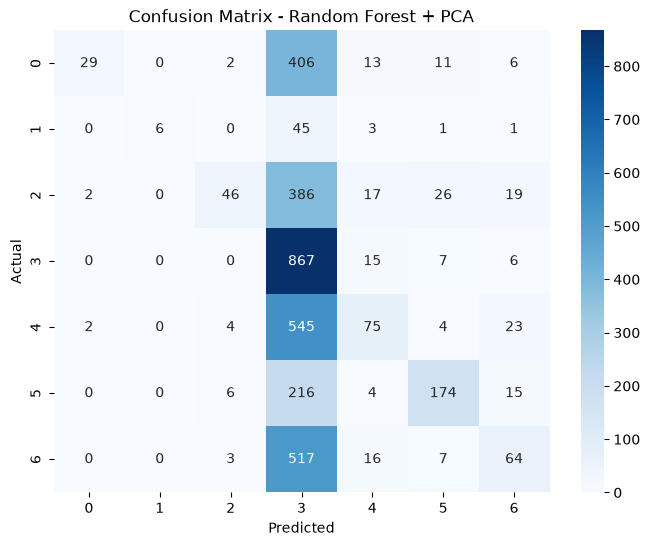

In [50]:

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf_pca, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Random Forest + PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

SVM + PCA

In [51]:
svm_pca = SVC(
    kernel='rbf',
    random_state=42
)

svm_pca.fit(X_pca_train_scaled, labelsTrain)

print("SVM + PCA trained successfully")

SVM + PCA trained successfully


Evaluate SVM + PCA in the validation test

In [52]:
y_pred_svm_pca = svm_pca.predict(X_pca_valid_scaled)

accuracy_svm_pca = accuracy_score(y_valid, y_pred_svm_pca)
baccuracy_svm_pca = balanced_accuracy_score(y_valid, y_pred_svm_pca)
macro_f1_svm_pca = f1_score(y_valid, y_pred_svm_pca, average='macro')

conf_matrix_svm_pca = confusion_matrix(y_valid, y_pred_svm_pca)

print(f"Accuracy: {accuracy_svm_pca:.2f}")
print(f"Balanced accuracy: {baccuracy_svm_pca:.2f}")
print(f"Macro F1: {macro_f1_svm_pca:.2f}")

Accuracy: 0.45
Balanced accuracy: 0.38
Macro F1: 0.40


Confusion Matrix - SVM + PCA

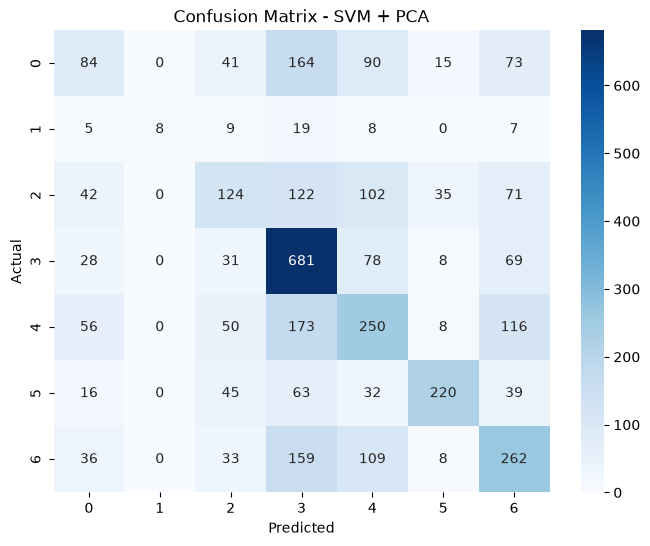

In [53]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm_pca, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - SVM + PCA")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()